# 1 — Introducción y teoría de la decisión

📓 [Notebook de clase](../raw/1_intro_teoria_decision.ipynb) · ✏️ [Ejercicios](../exercises/1_intro_teoria_decision.ipynb) · 📕 *ESL* (Hastie, Tibshirani & Friedman) como referencia principal

> **TL;DR**
>
> - Toda la materia arranca de un supuesto: existe una distribución conjunta
>   $p(X, Y)$ que describe **completamente** el problema. Si la tuvieras, no
>   necesitarías nada más: cualquier pregunta sobre $Y$ dado $X$ se contesta
>   condicionando.
> - Pero una distribución **no es una predicción**. Para pasar de $p(Y \mid X)$ a
>   un valor concreto hace falta una **decisión**, y decidir bien exige decir
>   antes qué es "equivocarse": eso es la **función de pérdida**.
> - Con pérdida **0-1** en clasificación, la decisión óptima es quedarse con la
>   clase de mayor probabilidad posterior: la **regla de Bayes**,
>   $\hat{G}(x) = \arg\max_g p(g \mid X = x)$.
> - Con pérdida **cuadrática** en regresión, la decisión óptima es la **media
>   condicional**, $f(x) = E(Y \mid X = x)$. Todo el resto de la materia son
>   maneras distintas de aproximar esa esperanza.
> - $p(X, Y)$ es imposible de estimar en dimensión alta, y por eso **hay que
>   modelar**. Según cuánto modeles nacen las tres familias: generativos,
>   discriminativos y funciones discriminantes.

## 🗺️ Mapa de la clase

| Bloque de la clase | Celdas | Dónde lo explico |
|--------------------|--------|------------------|
| Introducción (portada) | 0 | — (no abre tema) |
| Notación | 1 | §0 |
| Notación › Matrices | 2 | §0 |
| Notación › Vectores | 3–7 | §0 |
| ¿Cuál es la relación entre el aprendizaje automático y la estadística? | 8 | §1 |
| Aprendizaje no supervisado | 9–10 | §1 |
| Aprendizaje Supervisado | 11–13 | §1 |
| Inferencia vs predicción › Predicción | 14 | §1 |
| Inferencia | 15 | §1 |
| ¿Cómo podemos formalizar esto? | 16 | §2 |
| Reglas de la probabilidad | 17–19 | §2 |
| Enfoque bayesiano › Ejemplo - Ajuste de una curva | 20 | §2 |
| Aprendizaje Supervisado | 21 | §3 |
| Veamos algunos ejemplos y tratemos de bajar esto | 22 | §3 |
| Aprendizaje Supervisado › Ejemplo 1 | 23–26 | §3 |
| Aprendizaje Supervisado › Ejemplo 2 | 27–33 | §4 |
| Aprendizaje Supervisado › Ejemplo 3 | 34 | §4 |
| Aprendizaje Supervisado › Ejemplo 4 - Regresión | 35 | §4 |
| ¿Problema resuelto? | 36 | §5 |
| Teoría de la decisión | 37 | §5 |
| Teoría de la decisión *a la Bishop* › Clasificación | 38 | §5 |
| Teoría de la decisión *a la Bishop* | 39–41 | §5 |
| Teoría de la decisión - Clasificación | 42–47 | §6 |
| Aprendizaje Supervisado - Clasificación | 48–50 | §7 |
| Aprendizaje Supervisado - Clasificación › Inferencia y decisión | 51 | §7 |
| Aprendizaje Supervisado - Clasificación | 52 | §7 |
| Teoría de la decisión - Regresión | 53–54 | §8 |
| Aprendizaje Supervisado - Regresión | 55 | §8 |

La celda 0 es la portada: dice que la clase va a "volcar un montón de
ingredientes" para después cocinarlos. Es literal — esta clase es casi toda
vocabulario y andamiaje, y el plato se arma recién en §5.


In [1]:
# Setup — estilo de gráficos (ver referencias/estilo_graficos.md) + imports comunes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})


---

## 0. Notación: el contrato de toda la materia

📓 celdas 1–7 · 📕 ESL §2.2

### La idea en criollo

Antes de cualquier cuenta, la clase se toma cuatro slides para fijar cómo se
escriben las cosas. Parece burocracia y no lo es: la notación de Hastie codifica
la **forma** de cada objeto en cómo se lo escribe. Mayúscula o minúscula,
negrita o no: cada una de esas decisiones te dice si estás mirando una variable
o una observación, un número o un vector, y de qué largo.

Pensalo como las unidades en física. Cuando escribís una fórmula y las unidades
no cierran, sabés que te equivocaste **sin necesidad de revisar la cuenta**. Acá
pasa lo mismo con las dimensiones: si un producto de matrices no encaja, la
fórmula está mal y te enterás de un vistazo.

> **Dónde se rompe la analogía.** Las unidades del SI están estandarizadas en
> todo el mundo; esta notación no. Bishop escribe lo mismo de otra forma, y la
> propia clase va a mezclar las dos convenciones en §5 y §6 sin avisar
> demasiado. Así que no es "la" notación: es **un** dialecto, el de ESL, que es
> el que adopta la cátedra.

### Formalizándolo

Los tamaños:

- $N$ es el número de **observaciones** (a veces aparece como $n$).
- $p$ es el número de **variables de entrada**.

Las variables, en mayúscula, porque son entes simbólicos y genéricos:

- $X$ es la variable de entrada. Es un vector, y sus componentes son
  $X_1, X_2, \ldots, X_p$.
- $Y$ es una variable de salida **cuantitativa**: toma valores numéricos.
- $G$ es una variable de salida **cualitativa** ($G$ de *grupo*): toma valores en
  un conjunto finito $\mathcal{G} = \{1, 2, \ldots, K\}$, donde $K$ es el número
  de clases.

Guardate esa distinción, porque es la que parte la materia en dos: $Y$ te lleva a
regresión, $G$ te lleva a clasificación.

Las observaciones, en minúscula:

- $x_{i,j}$ es el valor observado de la variable $j$-ésima en la instancia
  $i$-ésima. La regla mnemotécnica de la clase es directa: **variables en
  mayúscula, observaciones en minúscula**.

Las matrices, en mayúscula y negrita. $\textbf{X}$ es la matriz de datos, de
$N \times p$ — **una fila por observación, una columna por variable**:

$$\textbf{X} = \begin{bmatrix}
x_{1,1} & x_{1,2} & \cdots & x_{1,p} \\
x_{2,1} & x_{2,2} & \cdots & x_{2,p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N,1} & x_{N,2} & \cdots & x_{N,p}
\end{bmatrix}$$

Y acá viene la convención más fina de todas, la que más confusión genera. Hay
dos tipos de vector dando vueltas y se distinguen **por la negrita**:

- **Sin** negrita, $x_i$: la observación $i$-ésima. Tiene $p$ componentes, una
  por variable. Es una **fila** de la tabla.
- **Con** negrita, $\textbf{x}_j$: todas las observaciones de la variable
  $j$-ésima. Tiene $N$ componentes. Es una **columna** de la tabla.

La negrita, entonces, marca "esto tiene $N$ componentes". Con eso, $\textbf{X}$
se puede escribir de dos maneras. Apilando columnas:

$$\textbf{X} = \begin{bmatrix} \textbf{x}_1 & \textbf{x}_2 & \cdots & \textbf{x}_p \end{bmatrix}$$

o apilando filas:

$$\textbf{X} = \begin{bmatrix} x_1^T \\ x_2^T \\ \vdots \\ x_N^T \end{bmatrix}$$

¿Por qué aparece esa transpuesta en la segunda? Por una convención que la clase
enuncia y conviene tatuarse: **todos los vectores se asumen vectores columna**.
Si $x_i$ es una columna de $p$ componentes, para que entre como *fila* de
$\textbf{X}$ hay que acostarlo, y acostar un vector es transponerlo. De ahí el
$x_i^T$.

### ¿Por qué nos importa?

Porque te permite **leer una fórmula sin entenderla todavía**, solo mirando las
formas. Tomá la que vas a ver en la próxima clase:

$$\hat\beta = (\textbf{X}^T\textbf{X})^{-1}\textbf{X}^T\textbf{y}$$

Sin saber qué es $\hat\beta$ podés reconstruir su tamaño. $\textbf{X}$ es
$N \times p$, así que $\textbf{X}^T$ es $p \times N$ y el producto
$\textbf{X}^T\textbf{X}$ es $p \times p$ — chiquito, no depende de cuántos datos
tengas. Su inversa sigue siendo $p \times p$. Multiplicada por
$\textbf{X}^T\textbf{y}$, que es $(p \times N)(N \times 1) = p \times 1$, queda
$p \times 1$. Conclusión: $\hat\beta$ es un vector con **una componente por
variable**. Que es exactamente lo que tiene que ser.

Ese chequeo lleva cinco segundos y te salva de la mitad de los errores de
álgebra que vas a cometer en la materia.

### En código

La clase mete tres celdas de código sueltas acá (5, 6 y 7) que parecen no venir a
cuento. Sí vienen: son la versión `numpy` de la convención "una fila por
observación".


In [2]:
X_train = np.array([1, 2, 3])
print("array 1-D:", X_train.shape)   # ni fila ni columna

X_train = np.array([1, 2, 3]).reshape(3, 1)
print("reshape(3, 1):", X_train.shape)   # N=3 observaciones, p=1 variable

from sklearn.preprocessing import StandardScaler

# scikit-learn exige (N, p) SIEMPRE, aunque p sea 1 -> ese reshape no es capricho
escalado = StandardScaler().fit_transform(X_train)
print("escalado:\n", escalado.ravel())


array 1-D: (3,)
reshape(3, 1): (3, 1)
escalado:
 [-1.22474487  0.          1.22474487]


`(3,)` y `(3, 1)` **no son lo mismo**. El primero es un array unidimensional, que
no es ni fila ni columna; el segundo es la matriz $\textbf{X}$ de la teoría, con
$N = 3$ y $p = 1$. La celda de arriba lo confirma: `StandardScaler` acepta el
segundo, y con el primero tira `ValueError: Expected 2D array, got 1D array
instead` — es literalmente este tema. Ese `reshape(3, 1)` no es un capricho de
la librería: es la convención de la teoría hecha código.

### ⚠️ Confusión típica

**Primera:** confundir $X$ con $x_i$ con $\textbf{x}_j$. Cuando veas un símbolo
en una fórmula, preguntate siempre lo mismo: ¿esto tiene $p$ componentes o $N$?
La respuesta está en la negrita.

**Segunda:** el `ValueError: Expected 2D array, got 1D array instead` de
`sklearn`, que acabás de ver arriba. Pasaste un `(N,)` donde iba un `(N, 1)`.

**Tercera, y la más traicionera:** la clase dice en la celda 11 que "si $Y$ es
una variable categórica, entonces $\hat{Y}$ tomará valores en el conjunto de
categorías $G$". Hay dos deslices ahí: si la salida es categórica el estimador se
llama $\hat{G}$ (no $\hat{Y}$), y el conjunto de categorías es $\mathcal{G}$ (con
la letra caligráfica), no $G$. La propia clase se corrige en la celda 21, donde
lo escribe bien. Quedate con la versión de la celda 21.


---

## 1. Los dos aprendizajes y los dos objetivos

📓 celdas 8–15 · 📕 ESL §2.1 y cap. 14 · 📗 ISL §2.1.1

### La idea en criollo

Hay dos situaciones bien distintas según qué te dieron.

En **aprendizaje supervisado** te dan pares: para cada observación, los atributos
*y* la respuesta correcta. Es estudiar con el solucionario al lado: intentás,
comparás con la respuesta, corregís.

En **aprendizaje no supervisado** te dan una pila de datos sin ninguna respuesta
y la pregunta es mucho más vaga: *¿qué podés decir sobre estos datos?* Es que te
entreguen una caja de fotos desordenadas y te pidan que las agrupes, sin decirte
según qué criterio.

> **Dónde se rompe la analogía.** El solucionario de un libro es correcto por
> definición. Acá no: los $y_i$ que te dan son mediciones, y las mediciones
> vienen con ruido, error de tipeo, criterios que cambian entre quien etiquetó
> uno y quien etiquetó otro. Ese ruido tiene nombre en la fórmula de abajo —se
> llama $\epsilon$— y es justamente lo que hace que el problema no se pueda
> resolver perfecto ni con infinitos datos. No estás copiando un solucionario:
> estás tratando de adivinar la regla a partir de un solucionario borroneado.

### Formalizándolo

El punto de partida del aprendizaje supervisado es un conjunto de entrenamiento

$$T = \{(x_i, y_i)\}_{i=1}^{N}$$

y el supuesto de que existe una relación

$$Y = f(X) + \epsilon$$

Vale la pena desarmar esa igualdad término por término, porque es la ecuación
sobre la que se apoya toda la materia:

- $f(X)$ es la parte **sistemática**: todo lo que las variables de entrada
  efectivamente dicen sobre la salida. Es una función desconocida y fija.
- $\epsilon$ (léelo "épsilon") es el **error aleatorio**: todo lo que hace variar
  a $Y$ y que $X$ no captura. Variables que no medimos, ruido del instrumento,
  azar genuino.
- $Y$, entonces, no está determinada por $X$. Para un mismo $x$ podés observar
  distintos $y$.

Lo que produce el algoritmo de aprendizaje es una aproximación $\hat{f}$ (léelo
"efe sombrero"), construida a partir de $T$. El sombrero, en general, se lee
siempre igual: *"esto lo estimé a partir de datos"*, en oposición al objeto
verdadero sin sombrero, que nunca vamos a conocer.

Y las predicciones se escriben $\hat{Y} = \hat{f}(X)$.

El mecanismo del aprendizaje, tal como lo describe la celda 13, es la corrección
por error: el algoritmo mira las diferencias $y_i - \hat{f}(x_i)$ y ajusta la
relación entrada–salida para achicarlas. A eso se lo llama **aprendizaje por
ejemplos**, y esa diferencia $y_i - \hat{f}(x_i)$ —el **residuo**— va a ser el
protagonista de la próxima clase.

Sobre esa base, la clase separa dos **objetivos** que se persiguen con el mismo
modelo:

| | **Predicción** | **Inferencia** |
|---|---|---|
| Qué querés | un $\hat{y}$ para un $x$ nuevo | entender la relación entre $\textbf{X}$ e $y$ |
| La pregunta | ¿cuánto va a dar? | ¿qué predictores importan? ¿cómo? ¿es lineal? |
| Situación típica | los atributos son fáciles de conseguir, las etiquetas no | tenés los datos, te falta la explicación |
| Ejemplo de la clase | $\textbf{X}$: análisis de sangre → $y$: embarazo o no | $\textbf{X}$: análisis y estudios clínicos → $y$: diagnóstico de una enfermedad rara |
| Te sirve un modelo… | opaco, si acierta | interpretable, aunque acierte un poco menos |

### ¿Por qué nos importa?

Porque **el objetivo cambia el modelo que elegís**, no solo cómo lo mirás
después.

Si querés predecir, una red neuronal con un millón de parámetros que acierta
mejor es una respuesta perfectamente buena, aunque nadie pueda explicar por qué
decide lo que decide. Si querés inferir, ese mismo modelo no te sirve para nada,
y una regresión lineal que acierta peor pero cuyos coeficientes podés leer e
interpretar es estrictamente mejor.

Y $\epsilon$ importa por una razón brutal: **pone un piso al error que nadie
puede bajar**. Aunque conocieras $f$ exactamente —no una aproximación: la
función verdadera— seguirías equivocándote, porque $Y$ tiene una parte que no
depende de $X$. Ese piso reaparece con nombre propio en §5 (error de Bayes) y va
a ser el término irreducible de la descomposición sesgo–varianza más adelante en
📕 ESL §7.3.

### En código

La celda 10 no ilustra ninguna fórmula: ilustra qué se ve cuando **no hay
etiquetas**. Reproducimos exactamente lo que hace la clase, en una y dos
dimensiones.


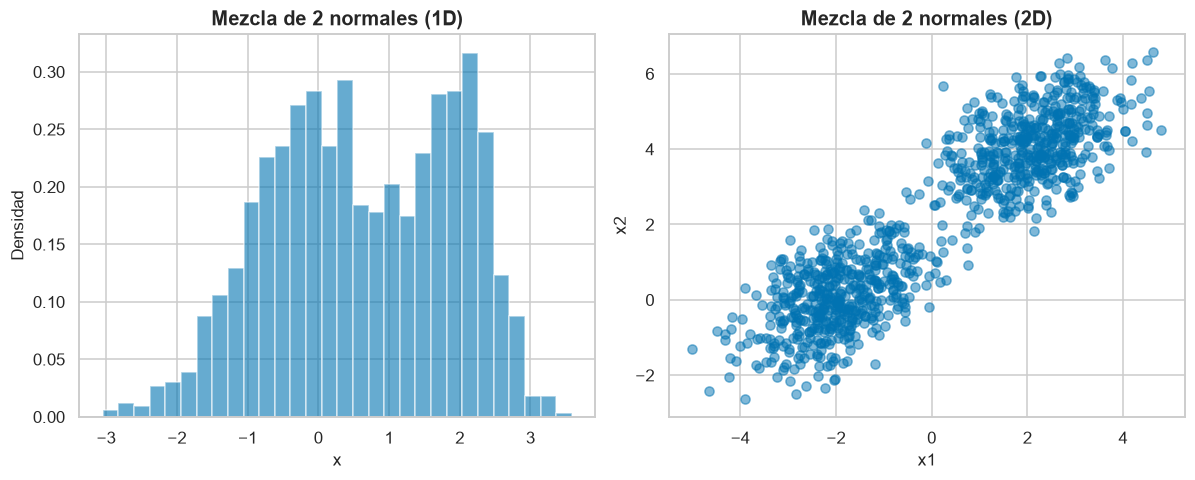

In [3]:
rng_legacy = np.random.RandomState(0)  # mismo seed que usó la clase (np.random.seed(0))

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

# --- 1D: mezcla de dos normales -------------------------------------------
x_1 = rng_legacy.normal(0, 1, 1000)
x_2 = rng_legacy.normal(2, 0.5, 500)
x = np.concatenate([x_1, x_2])

axs[0].hist(x, bins=30, density=True, alpha=0.6)
axs[0].set_xlabel("x")
axs[0].set_ylabel("Densidad")
axs[0].set_title("Mezcla de 2 normales (1D)")

# --- 2D: dos nubes gaussianas ----------------------------------------------
x_1 = rng_legacy.multivariate_normal(mean=[-2, 0], cov=[[1, 0.5], [0.5, 1]], size=500)
x_2 = rng_legacy.multivariate_normal(mean=[2, 4], cov=[[1, 0.5], [0.5, 1]], size=500)
x2d = np.concatenate([x_1, x_2])

axs[1].scatter(x2d[:, 0], x2d[:, 1], alpha=0.5)
axs[1].set_xlabel("x1")
axs[1].set_ylabel("x2")
axs[1].set_title("Mezcla de 2 normales (2D)")

plt.tight_layout()
plt.show()


Lo importante es qué se ve: el histograma tiene **dos jorobas**, y el gráfico
de la derecha muestra **dos nubes** bien separadas. Nadie te dijo que había dos
grupos, no hay ninguna $y$ en el código, y sin embargo la estructura está ahí, a
la vista. Eso es aprendizaje no supervisado: leer estructura de $X$ sin ninguna
etiqueta que te guíe.

### ⚠️ Confusión típica

Leer $Y = f(X) + \epsilon$ como si $\epsilon$ fuera "el error de mi modelo". No
lo es. $\epsilon$ está en la **realidad**, no en tu modelo: existe antes de que
vos ajustes nada y sigue existiendo después. Tu modelo tiene su propio error —la
diferencia entre $\hat{f}$ y $f$— y ese sí se puede achicar con más datos o
mejores algoritmos. El de $\epsilon$ no.

La segunda: creer que "supervisado" y "no supervisado" son propiedades del
*dataset*. Son propiedades de **la pregunta que le hacés**. Con los mismos datos
de compras podés hacer aprendizaje supervisado (predecir si un cliente se va a
dar de baja, si tenés esa etiqueta) o no supervisado (segmentar clientes en
grupos parecidos). Los datos son los mismos; el problema, no.

### ❓ Las preguntas que quedaron abiertas

La celda 8 es un título entero — *"¿Cuál es la relación entre el aprendizaje
automático y la estadística?"*— y la clase nunca la responde: pasa directo a los
dos tipos de aprendizaje. Te dejo la respuesta corta.

Son la misma matemática con dos culturas encima. La estadística clásica nació
para hacer **inferencia** con pocos datos y muchos supuestos: le importa si un
coeficiente es significativo, si el modelo está bien especificado, si el
intervalo de confianza cubre. El aprendizaje automático nació del lado de la
computación, con muchos datos y pocos supuestos, y le importa casi solo una cosa:
si el modelo **anda bien con datos que nunca vio**. Cambia el vocabulario
(*features* por variables, *training* por estimación, *weights* por parámetros),
cambia qué se considera una respuesta aceptable, pero el aparato es el mismo, y
esta materia lo trata como uno solo. Que la propia clase cite a Hastie y a Bishop
lado a lado es la mejor prueba: uno es un libro de estadística, el otro de
reconocimiento de patrones, y hablan del mismo tema.

La celda 9 pregunta *"¿qué puedo decir sobre $X$?"* sin contestar tampoco. Se
puede decir bastante: qué grupos hay (*clustering*), en qué direcciones varían
más los datos (PCA, 📕 ESL §14.5), qué observaciones son raras (detección de
anomalías), qué densidad los generó. La materia vuelve a eso en el capítulo 14 de
ESL; por ahora alcanza con saber que la pregunta tiene respuestas.


---

## 2. El lenguaje formal: dos reglas y todo lo demás

📓 celdas 16–20 · 📘 Bishop §1.2

### La idea en criollo

La celda 16 es un título solo: *"¿Cómo podemos formalizar esto?"*. Lo que sigue
es la respuesta, y es más chica de lo que uno esperaría: **dos reglas**. Todo el
aparato probabilístico de la materia —Bayes, marginales, condicionales, el
enfoque bayesiano entero— sale de combinar esas dos.

La regla de la suma es literalmente la de una tabla de doble entrada. Si tenés
las probabilidades de cada celda y querés la de una fila, sumás la fila. El
nombre técnico de eso —**marginal**— viene de ahí: es el numerito que quedaba
anotado **al margen** de la tabla.

> **Dónde se rompe la analogía.** La tabla es finita y la podés sumar a mano.
> Cuando $X$ es continua, "sumar la fila" pasa a ser integrar, y cuando $X$ tiene
> 50 componentes la tabla tendría más celdas que átomos hay en el universo
> observable. Las reglas siguen valiendo idénticas; lo que se rompe es la
> posibilidad de **calcularlas**. Ese muro es el tema de §7.

### Formalizándolo

**Caso discreto.** Las dos reglas:

$$\text{suma:}\quad p(X) = \sum_{Y} p(X, Y) \qquad\qquad \text{producto:}\quad p(X, Y) = p(Y \mid X)\, p(X)$$

La de la suma dice que para quedarte con una sola variable, barrés todos los
valores posibles de la otra. A eso se lo llama **marginalizar**.

La del producto dice que la probabilidad de que pasen dos cosas es la
probabilidad de que pase la primera, por la de que pase la segunda **dado que la
primera pasó**.

**El teorema de Bayes.** La clase dice que las dos reglas "se pueden combinar"
para obtenerlo, y muestra el resultado. Hagamos la combinación, que son tres
líneas y despeja el misterio.

La regla del producto no distingue el orden en que descomponés: podés
condicionar $Y$ a $X$ o al revés. Las dos descripciones son de la misma conjunta,
así que valen las dos a la vez:

$$p(X, Y) = p(Y \mid X)\, p(X) \qquad\text{y}\qquad p(X, Y) = p(X \mid Y)\, p(Y)$$

Como el miembro izquierdo es el mismo, los derechos son iguales entre sí:

$$p(Y \mid X)\, p(X) = p(X \mid Y)\, p(Y)$$

Dividís por $p(X)$ (suponiendo $p(X) > 0$) y ya está:

$$\boxed{\;p(Y \mid X) = \frac{p(X \mid Y)\, p(Y)}{p(X)}\;}$$

Eso es todo el teorema de Bayes: la regla del producto escrita dos veces y
despejada. Y el denominador sale de aplicar las **dos** reglas juntas —primero
la de la suma, después la del producto sobre cada término—:

$$p(X) = \sum_{Y} p(X, Y) = \sum_{Y} p(X \mid Y)\, p(Y)$$

Ese denominador no aporta información: es el mismo para todos los valores de $Y$.
Su único trabajo es **normalizar**, es decir, hacer que las probabilidades
sumen 1. Por eso más adelante vas a ver a Bayes escrito como
$p(Y \mid X) \propto p(X \mid Y)\, p(Y)$, ignorándolo: cuando lo único que querés
es saber **cuál** $Y$ es más probable, dividir a todos por el mismo número no
cambia el ranking. Ese atajo va a ser central en §5.

**Caso continuo.** Cambian tres cosas y nada más. Las probabilidades pasan a ser
áreas bajo una curva:

$$p(x \in (a,b)) = \int_a^b p(x)\, dx \qquad\qquad \int_{-\infty}^{\infty} p(x)\, dx = 1$$

y las sumas pasan a ser integrales:

$$\text{suma:}\quad p(x) = \int p(x, y)\, dy \qquad\qquad \text{producto:}\quad p(x, y) = p(y \mid x)\, p(x)$$

Fijate que la regla del producto es **idéntica**. La única que cambia de forma es
la de la suma, y solo porque sumar sobre un continuo se llama integrar.

**El enfoque bayesiano.** La celda 20 introduce un cambio de perspectiva que va a
volver muchas veces. El argumento de arranque es que hay eventos que no se dejan
pensar como frecuencias: ¿cuál es la "frecuencia" de que se derrita el casquete
polar antes de 2050? No hay repeticiones que contar. Pero sí tenés un **grado de
creencia**, y podés actualizarlo cuando llegan datos nuevos.

Aplicado a ajustar un modelo, Bayes se escribe así:

$$p(\textbf{w} \mid \mathcal{D}) = \frac{p(\mathcal{D} \mid \textbf{w})\, p(\textbf{w})}{p(\mathcal{D})}, \qquad p(\mathcal{D}) = \int p(\mathcal{D} \mid \textbf{w})\, p(\textbf{w})\, d\textbf{w}$$

donde $\mathcal{D}$ es el conjunto de datos observados y $\textbf{w}$ los
parámetros del modelo (es la notación de Bishop; en ESL los parámetros se llaman
$\beta$). Cada pieza tiene nombre propio:

- $p(\textbf{w})$ es el **prior**: lo que creías de los parámetros antes de ver
  un solo dato.
- $p(\mathcal{D} \mid \textbf{w})$ es la **verosimilitud**: qué tan compatibles
  son los datos que viste con cada valor de los parámetros.
- $p(\textbf{w} \mid \mathcal{D})$ es el **posterior**: lo que creés después.

La diferencia de fondo con el enfoque frecuentista es **quién es la variable
aleatoria**, y la clase lo dice de forma muy limpia:

| | Frecuentista | Bayesiano |
|---|---|---|
| Los parámetros son… | fijos, desconocidos | variables aleatorias, con distribución |
| Los datos son… | variables aleatorias | fijos (son los que observaste) |
| Las barras de error salen de… | la distribución de los **datos** (¿qué pasaría si repitiera el experimento?) | la distribución de los **parámetros** (¿cuánta incerteza me queda?) |

### ¿Por qué nos importa?

Porque a partir de acá, cada vez que la materia diga "condicionamos", "sacamos la
marginal" o "por Bayes", está haciendo una de estas dos cosas. No hay una tercera
regla escondida más adelante.

Y en particular: la frase de la próxima sección —*"si tenés $p(X,Y)$, problema
resuelto"*— es exactamente esto. Tener la conjunta y aplicar producto y suma te
da cualquier condicional y cualquier marginal que quieras.

### En código

Concretemos las dos reglas sobre una tabla chiquita, porque en abstracto suenan
más difíciles de lo que son.


In [4]:
# p_conj[x, y] = P(X=x, Y=y). Las filas son X (3 valores), las columnas Y (2).
p_conj = np.array([[0.20, 0.10],
                    [0.15, 0.25],
                    [0.05, 0.25]])

# Regla de la suma: marginalizar Y para quedarme con p(X).
p_X = p_conj.sum(axis=1)

# Regla del producto despejada: p(Y|X) = p(X,Y) / p(X).
# El reshape es para que numpy divida cada FILA por su propio p(X).
p_Y_dado_X = p_conj / p_X.reshape(-1, 1)

print("p(X):", p_X, "  suma:", p_X.sum())
print("p(Y|X), suma por fila:", p_Y_dado_X.sum(axis=1))


p(X): [0.3 0.4 0.3]   suma: 1.0
p(Y|X), suma por fila: [1. 1. 1.]


El chequeo de la última línea es el que conviene automatizar siempre: una
distribución condicional **tiene que sumar 1 para cada valor condicionante**
(la salida de arriba lo confirma: `[1. 1. 1.]`). Si no da 1, dividiste por la
marginal equivocada — el error más común de todos es marginalizar sobre el eje
que no era.

### ⚠️ Confusión típica

En el caso continuo, $p(x)$ **no es una probabilidad**: es una *densidad*. Puede
valer más que 1 sin ningún problema. Una normal muy angosta, digamos con
$\sigma = 0{,}01$, alcanza casi 40 en su pico. Lo que nunca puede pasar de 1 es
el **área**, que es la probabilidad de verdad. Por eso $p(x = 3) = 0$ exactamente
para cualquier variable continua, y solo tiene sentido preguntar por intervalos.

La segunda: confundir $p(Y \mid X)$ con $p(X \mid Y)$. No son lo mismo ni se
parecen. La probabilidad de que llueva dado que hay nubes es alta; la de que haya
nubes dado que llueve es prácticamente 1. Todo el teorema de Bayes existe
justamente porque son distintas, y sirve para pasar de la que podés medir a la
que querés.


---

## 3. La distribución conjunta lo resuelve todo (si la tuvieras)

📓 celdas 21–26 · 📕 ESL §2.4 · 📘 Bishop §1.5

### La idea en criollo

Acá la clase pone la piedra fundamental de toda la materia, y conviene decirla
sin rodeos: **el problema de aprendizaje, en su forma más general, es determinar
$p(X, Y)$**. Si conocieras esa distribución conjunta, se te terminaron los
problemas de modelado — cualquier pregunta sobre $Y$ dado $X$ se responde
condicionando, con las dos reglas de §2.

Pensalo como tener el censo completo de un país, con todas las variables de todas
las personas. Cualquier pregunta ("¿qué proporción de la gente de tal edad, en
tal provincia, tiene tal característica?") se contesta filtrando y contando. No
hace falta *modelar* nada: alcanza con consultar.

> **Dónde se rompe la analogía.** El censo es una tabla finita que existe en un
> servidor. $p(X, Y)$ es un objeto matemático que **nadie te va a dar**. En esta
> sección la clase te la regala para mostrarte qué se puede hacer con ella; el
> resto de la materia es aceptar que no la tenés y arreglártelas igual. Guardá
> esa distinción, porque es la bisagra entre esta sección y §7.

### Formalizándolo

La celda 21 lo enuncia así: dado
$\{(x_1,y_1), \ldots, (x_N,y_N)\}$, el objetivo es aprender la relación entre $X$
e $Y$ para predecir $\hat{y}$ ante un $x$ nuevo. Y separa las dos ramas:

- **Regresión**: $Y$ toma valores continuos.
- **Clasificación**: la salida son etiquetas de clase y, para ser consistentes,
  hay que llamarla $G$. El estimador $\hat{G}$ toma valores en el mismo conjunto
  $\mathcal{G}$ que $G$.

Y entonces viene la afirmación central, con su justificación en una línea: la
conjunta $p(X,Y)$ es la **descripción probabilística más completa** que se puede
hacer del problema, porque con ella y el teorema de Bayes ya podés predecir:

$$p(Y = y \mid X = x) = \frac{p(X = x, Y = y)}{p(X = x)}$$

**Ejemplo 1: la materia que hay que aprobar.** Para bajarlo a tierra, la clase
arma un ejemplo de juguete donde la conjunta se puede escribir entera. Se quiere
predecir si alguien aprueba ($Y = 1$) o no ($Y = 0$) a partir de:

- $X_1$: horas de estudio, con valores en $\{0, 1, 2, 3, 4\}$
- $X_2$: si asistió a clases, con valores en $\{0, 1\}$

Son $5 \times 2 = 10$ combinaciones de atributos, cada una con dos valores
posibles de salida: 20 números en total. Así se ve la tabla de la conjunta
$P(X_1, X_2, Y)$ que mostraba la clase:


![Tabla de la conjunta P(X1, X2, Y): en cada celda, arriba P(x1,x2,Y=0) y abajo P(x1,x2,Y=1)](../../figuras/Tabla%20ejemplo%20p%20conjunta.png)

*(En cada celda, arriba $P(x_1, x_2, Y{=}0)$ y abajo $P(x_1, x_2, Y{=}1)$.)*

Antes de seguir, dos chequeos que valen la pena hacer con los dedos — y que
verificamos con código más abajo:

1. **Los 20 números suman 1.** La fila $X_2 = 0$ suma $0{,}50$ y la $X_2 = 1$
   también. Total: 1. Es una distribución de probabilidad legítima.
2. **Cada celda suma $0{,}10$.** Por ejemplo $0{,}09 + 0{,}01 = 0{,}10$, y
   $0{,}005 + 0{,}095 = 0{,}10$. Esto es $P(X_1 = x_1, X_2 = x_2)$, la marginal
   de los atributos, y da lo mismo en las diez celdas. La clase lo dice
   explícitamente: está construido así **para facilitar las cuentas**, no porque
   tenga que ser así.

Con eso, condicionar es dividir por $0{,}10$:

$$P(Y = 1 \mid X_1 = x_1, X_2 = x_2) = \frac{P(x_1, x_2, Y = 1)}{P(x_1, x_2)}$$

y la tabla condicional que resulta es esta:

![Tabla condicional P(Y | X1, X2): la probabilidad de aprobar para cada perfil de alumno](../../figuras/Tabla%20ejemplo%20p%20condicional.png)

Leela: cada celda te dice, para un perfil de alumno, la probabilidad de aprobar.
Alguien que estudió 4 horas y fue a clase tiene $0{,}95$ de aprobar; alguien que
estudió 0 y no fue, $0{,}1$. **Eso es una descripción completa del problema.**

Y fijate un detalle que va a ser importante en §5: en la celda $X_1 = 3$,
$X_2 = 0$ la condicional da $0{,}5$ y $0{,}5$. Empate perfecto. Ahí, decidas lo
que decidas, te equivocás la mitad de las veces. No hay modelo que arregle eso.

### ¿Por qué nos importa?

Porque establece el **techo teórico** contra el cual se mide todo lo demás.
Cuando en clases posteriores compares modelos, la pregunta de fondo va a ser
siempre la misma: ¿cuánto te acercás a lo que haría alguien que conociera
$p(X, Y)$?

Y porque deja preparada la trampa que la clase va a resortear en §5: **tener la
distribución no es tener la predicción**. Mirá la tabla condicional otra vez. Te
dice probabilidades. Si te preguntan "¿este alumno aprueba, sí o no?", la tabla
sola no contesta. Falta un paso, y ese paso es teoría de la decisión.

### En código

Podés reconstruir las dos tablas y verificar todo lo anterior en diez líneas.


In [5]:
# conj[x1, x2, y] = P(X1=x1, X2=x2, Y=y), con x1 en 0..4, x2 en 0..1, y en 0..1
conj = np.array([
    [[0.09, 0.01], [0.08, 0.02]],     # X1 = 0
    [[0.07, 0.03], [0.04, 0.06]],     # X1 = 1
    [[0.06, 0.04], [0.03, 0.07]],     # X1 = 2
    [[0.05, 0.05], [0.02, 0.08]],     # X1 = 3
    [[0.01, 0.09], [0.005, 0.095]],   # X1 = 4
])

print("suma total:", conj.sum())            # 1.0 -> es una distribución válida

p_x = conj.sum(axis=2)                      # marginal de los atributos: regla de la suma
print("p(X1, X2), todas 0.1:\n", p_x)

p_y_dado_x = conj / p_x[:, :, None]         # condicional: regla del producto despejada
print("P(Y | X1=3, X2=0):", p_y_dado_x[3, 0])   # el empate de la teoría


suma total: 1.0
p(X1, X2), todas 0.1:
 [[0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]
 [0.1 0.1]]
P(Y | X1=3, X2=0): [0.5 0.5]


El `[:, :, None]` es el mismo truco del `reshape` de §2: agrega un eje para que
`numpy` divida cada par de valores de $Y$ por la marginal de **su** celda. La
salida confirma el empate perfecto que predecía la teoría: `[0.5 0.5]`.

### ⚠️ Confusión típica

Salir de esta sección pensando que el problema está resuelto. La clase avisa en
negrita en la celda 26, y conviene subrayarlo: **en ningún momento se dijo cómo
obtener la tabla original**. Nos la regalaron. En un problema de verdad, esa
tabla es exactamente lo que no tenés, y conseguirla es el problema entero.

La segunda: creer que la conjunta y la condicional contienen la misma
información. La conjunta contiene más. De $P(X, Y)$ salen la condicional **y** la
marginal $P(X)$; de la condicional sola, no podés recuperar $P(X)$. Perdiste el
dato de qué tan frecuente es cada perfil de alumno. Para *decidir* no lo
necesitás —y por eso §5 lo va a poder tirar—, pero para saber cuánto pesa cada
error en el total, sí.

### ❓ La pregunta que quedó abierta

La celda 26 cierra con dos preguntas y pasa a otra cosa: *"¿Cuál les parece más
cómoda para trabajar? ¿Cuál es más fácil de medir?"*, comparando la tabla
conjunta con la condicional.

**Más cómoda para trabajar** es la condicional. Ya viene con la respuesta que
querés (la probabilidad de aprobar dado el perfil) y no hay que dividir por nada.

**Más fácil de medir** es también la condicional, y por una razón práctica que
importa mucho: para estimarla te alcanza con juntar alumnos de cada perfil y
contar qué fracción aprobó. No necesitás que tu muestra tenga las proporciones
correctas de cada perfil. Para estimar la **conjunta**, en cambio, sí: si en tu
muestra sobrerrepresentaste a los que fueron a clase, la conjunta te va a salir
sesgada, aunque cada condicional esté perfecta.

Y ese es exactamente el argumento que separa los modelos **generativos** de los
**discriminativos** en §7: modelar menos cosas es modelar cosas más fáciles de
medir. La pregunta de la celda 26 no era retórica: era el anticipo de esa
discusión.


---

## 4. Los otros tres ejemplos: de la tabla a los datos

📓 celdas 27–35

### La idea en criollo

El Ejemplo 1 era modo dios: alguien te pasó la tabla verdadera. Los ejemplos que
siguen bajan un escalón cada vez hacia la realidad.

El **Ejemplo 2** simula datos a partir de una conjunta conocida y después trata
de recuperarla contando. Es el ejercicio inverso al anterior y es el que se
parece a lo que vas a hacer siempre: no ves la tabla, ves muestras.

El **Ejemplo 3** la clase lo saltea ("clasificación, analítico → lo dejamos para
cuando veamos Análisis Discriminante"). Es una promesa, no un contenido: cuando
llegues a 📕 ESL §4.3 vas a ver ese caso resuelto con fórmulas cerradas.

El **Ejemplo 4** cambia de rama: en vez de clases, un target continuo, y muestra
la conjunta escrita como una fórmula en vez de como una tabla.

> **Dónde se rompe la analogía** de "contar para recuperar la tabla": funciona
> acá porque hay 10 celdas y 100 observaciones por celda. Con dos atributos
> continuos ya no podés contar nada — no hay dos observaciones que caigan en el
> mismo punto. Ahí es donde contar se vuelve modelar, que es todo el Ejemplo 4.

### Formalizándolo

**Ejemplo 2 (celdas 27–33).** El código genera datos con una $P(Y = 1 \mid X_1, X_2)$
fijada a mano, 100 observaciones por celda, y después estima esa misma
probabilidad como el **promedio de $Y$** en cada celda.

Ese truco merece una explicación, porque se usa todo el tiempo y casi nunca se
justifica: cuando $Y$ solo toma valores 0 y 1, el promedio **es** la
probabilidad. Formalmente,

$$E[Y \mid X = x] = 0 \cdot P(Y = 0 \mid x) + 1 \cdot P(Y = 1 \mid x) = P(Y = 1 \mid x)$$

Por eso `df.pivot_table(..., aggfunc='mean')` estima una probabilidad
condicional. No es una aproximación: para variables binarias, esperanza y
probabilidad son el mismo número. Y de paso, esa igualdad es el puente exacto
entre §6 (clasificación) y §8 (regresión), donde el objeto óptimo va a ser
justamente una esperanza condicional.

Las últimas líneas calculan además las **marginales**
$P(Y = 1 \mid X_1)$ y $P(Y = 1 \mid X_2)$, agrupando por una sola variable. Eso
es la regla de la suma de §2 aplicada a datos: al agrupar solo por $X_1$ estás
promediando sobre todos los valores de $X_2$.

Vamos a reconstruir el ejemplo completo con código real: generamos los datos
con la $P(Y{=}1\mid X_1,X_2)$ que fija la clase y verificamos que el promedio
por celda la recupera.


In [6]:
rng = np.random.default_rng(0)

X1_vals = np.arange(0, 5)       # 0,1,2,3,4
X2_vals = np.array([0, 1])
n_per_cell = 100

# P(Y=1 | X1=i, X2=j) fijada a mano por la clase
p_table = {
    0: {0: 0.0, 1: 0.05},
    1: {0: 0.10, 1: 0.25},
    2: {0: 0.20, 1: 0.45},
    3: {0: 0.30, 1: 0.60},
    4: {0: 0.40, 1: 0.95},
}

rows = []
for i in X1_vals:
    for j in X2_vals:
        p1 = p_table[i][j]
        y_samples = rng.binomial(1, p1, size=n_per_cell)
        rows.extend({"X1": i, "X2": j, "Y": y} for y in y_samples)

df = pd.DataFrame(rows).sample(frac=1, random_state=0).reset_index(drop=True)
df.head()


,X1,X2,Y
0,4,1,1
1,4,0,1
2,1,0,1
3,2,1,0
4,3,0,0


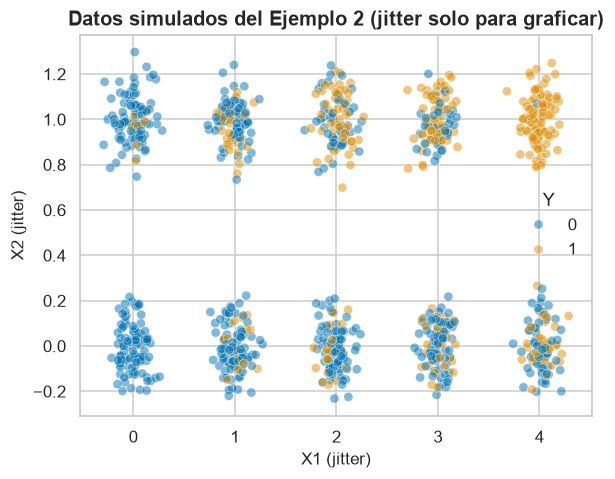

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))

# X1 y X2 son discretas: sin ruido, los 1000 puntos caen en solo 10 posiciones
# y se tapan entre sí. El jitter los desparrama para poder ver la densidad.
df["X1_jitter"] = df["X1"] + rng.normal(0, 0.1, size=len(df))
df["X2_jitter"] = df["X2"] + rng.normal(0, 0.1, size=len(df))

sns.scatterplot(data=df, x="X1_jitter", y="X2_jitter", hue="Y", alpha=0.5, ax=ax)
ax.set_xlabel("X1 (jitter)")
ax.set_ylabel("X2 (jitter)")
ax.set_title("Datos simulados del Ejemplo 2 (jitter solo para graficar)")
plt.show()


In [8]:
p_1_estimada = df.pivot_table(index="X1", columns="X2", values="Y", aggfunc="mean")
print("P(Y=1 | X1, X2) estimada contando:\n", p_1_estimada)

print("\nP(Y=1 | X1):\n", df.groupby("X1")["Y"].mean())
print("\nP(Y=1 | X2):\n", df.groupby("X2")["Y"].mean())


P(Y=1 | X1, X2) estimada contando:
 X2     0     1
X1            
0   0.00  0.08
1   0.14  0.32
2   0.20  0.53
3   0.29  0.62
4   0.41  0.99

P(Y=1 | X1):
 X1
0    0.040
1    0.230
2    0.365
3    0.455
4    0.700
Name: Y, dtype: float64

P(Y=1 | X2):
 X2
0    0.208
1    0.508
Name: Y, dtype: float64


Compará la tabla estimada con `p_table`: con 100 observaciones por celda ya se
parece bastante a los valores verdaderos (0.0, 0.05, 0.10, 0.25, …), aunque no
exacto — es una estimación, no la tabla regalada del Ejemplo 1. Con más
observaciones por celda, la estimación se acerca más.

**Ejemplo 4 (celda 35).** Acá la conjunta no es una tabla sino una fórmula: dos
atributos continuos normales y un target continuo que depende linealmente de
ellos más ruido gaussiano.

$$
\begin{aligned}
p(x_1, x_2, y) = & \underbrace{\frac{1}{2\pi |\Sigma_X|^{1/2}} \exp\left(-\frac{1}{2} (x - \boldsymbol{\mu}_X)^\top \Sigma_X^{-1} (x - \boldsymbol{\mu}_X)\right)}_{p(x_1, x_2)} \\[2mm]
& \times \underbrace{\frac{1}{\sqrt{2\pi}\,\sigma} \exp\left(-\frac{1}{2\sigma^2}\left[y - (\beta_0 + \beta_1 x_1 + \beta_2 x_2)\right]^2\right)}_{p(y \mid x_1, x_2)}
\end{aligned}
$$

La clase la presenta como un bloque y dice "es una descripción completa del
problema". Lo que no dice, y es lo más importante de la fórmula, es **por qué
está escrita como un producto de dos cosas**: porque es la regla del producto de
§2, $p(x, y) = p(x)\, p(y \mid x)$.

- El primer factor es una **normal multivariada** en $(x_1, x_2)$: modela cómo se
  distribuyen los atributos, sin decir nada de $y$.
- El segundo es una **normal univariada** en $y$, centrada en
  $\beta_0 + \beta_1 x_1 + \beta_2 x_2$ y con desvío $\sigma$: modela la salida
  dado los atributos.

Y si mirás ese segundo factor con atención, ya viste lo que dice: la media de $y$
dado $x$ es lineal en los atributos. Es decir, $E(Y \mid X) = \beta_0 + \beta_1 x_1 + \beta_2 x_2$.
Eso **es** el modelo de regresión lineal — el tema de la próxima clase—, acá
escrito como una distribución conjunta en vez de como una recta que ajusta
puntos. Guardate esa doble lectura: es la misma cosa vista desde los dos lados.

### ¿Por qué nos importa?

Porque cierra el círculo de la clase antes de teoría de la decisión. Los cuatro
ejemplos son el mismo objeto ($p(X, Y)$) en cuatro presentaciones: tabla
regalada, tabla estimada de datos, caso analítico prometido, y fórmula continua.
El mensaje es que "la conjunta" no es una cosa abstracta: es lo que ya estabas
mirando en cualquier dataset, escrito de otra manera.

### ⚠️ Confusión típica

Hay un comentario **incorrecto** en la celda 29 de la clase original, y conviene
que lo sepas para no volverte loco tratando de entenderlo. Decía:

```python
# Cada fila i suma a 1, garantizando P(Y=1|X1=i)=0.5
```

pero la tabla `p_table` de arriba es la que realmente define el ejemplo, y para
$X_1 = 0$ el promedio de las dos entradas es $(0{,}0 + 0{,}05)/2 = 0{,}025$, no
$0{,}5$. El comentario quedó de una versión anterior del ejemplo (por eso no
está en la celda de código de acá arriba). Los valores de `p_table` son
probabilidades de $Y = 1$ para cada combinación, y no suman ni promedian nada en
particular: están elegidos para que se vea una tendencia creciente.

La segunda: pensar que el Ejemplo 4 es "otro tema" porque aparece una fórmula
larga. Es el Ejemplo 1 con $X$ continua. La tabla se volvió una densidad, nada
más.


---

## 5. Teoría de la decisión: el camino de Bishop

📓 celdas 36–41 · 📘 Bishop §1.5.1

### La idea en criollo

La celda 36 es el giro de la clase, y está escrito como título para que no se te
pase: *"¿Problema resuelto? En todos los ejemplos, obtuvimos una distribución de
probabilidad, no una predicción."*

Tenés la tabla condicional del Ejemplo 1. Te preguntan: *este alumno estudió 2
horas y no fue a clase, ¿aprueba?* La tabla contesta "70% que no, 30% que sí".
Pero te pidieron un sí o un no. Convertir esa distribución en una respuesta
concreta es una **decisión**, y es un problema distinto del de estimar la
distribución.

Pensalo como el detector de metales de un aeropuerto. Mide una señal continua y
alguien tiene que elegir a partir de qué valor suena la alarma. Subís el umbral y
dejás pasar armas; lo bajás y hacés desnudar a media terminal por una hebilla. La
física del detector es una cosa; **dónde ponés el umbral** es otra, y es una
decisión.

> **Dónde se rompe la analogía.** En el aeropuerto los dos errores no cuestan lo
> mismo, ni por asomo. Esta sección, en cambio, asume que sí: minimiza la
> *cantidad* de errores, tratándolos a todos igual. Guardá esa incomodidad,
> porque es exactamente el agujero que §6 viene a tapar.

### Formalizándolo

El planteo de la celda 38, en tres pasos:

1. Se busca **minimizar la probabilidad de error** (que es lo mismo que
   maximizar la de acierto).
2. Hace falta una regla que asigne cada $X = x$ a una clase de $\mathcal{G}$. Esa
   regla parte el espacio de entrada en **regiones de decisión**: $\mathcal{R}_k$
   es el conjunto de puntos que se asignan a la clase $k$.
3. Las fronteras entre regiones se llaman **fronteras de decisión**. Y ojo con
   esto: una región **no tiene por qué ser contigua**. Puede estar hecha de
   varios pedazos sueltos.

Ahora la cuenta, para dos clases $C_1$ y $C_2$ con regiones $\mathcal{R}_1$ y
$\mathcal{R}_2$. Te equivocás de dos maneras posibles, y son mutuamente
excluyentes:

$$p(\text{error}) = p(x \in \mathcal{R}_1, y = C_2) + p(x \in \mathcal{R}_2, y = C_1)$$

En palabras: o el punto cayó en la región donde predecís $C_1$ pero en realidad
era $C_2$, o al revés. Escrito como integrales sobre cada región:

$$p(\text{error}) = \int_{\mathcal{R}_1} p(x, C_2)\, dx + \int_{\mathcal{R}_2} p(x, C_1)\, dx$$

Y ahora el paso que hace toda la magia. Aplicamos la regla del producto,
$p(x, C_k) = p(C_k \mid x)\, p(x)$:

$$p(\text{error}) = \int_{\mathcal{R}_1} p(C_2 \mid x)\, p(x)\, dx + \int_{\mathcal{R}_2} p(C_1 \mid x)\, p(x)\, dx$$

Mirá qué quedó: $p(x)$ aparece **en los dos términos**, multiplicando. Y $p(x)$
es siempre positiva. Eso significa que, para cada punto $x$ por separado, el
integrando es $p(x)$ —un peso que no controlás— por la posterior de la clase que
**no** elegiste —que sí controlás—.

Entonces, para hacer la integral lo más chica posible, en cada $x$ te conviene
mandar ese punto a la región de la clase cuya posterior sea **mayor**, para que
lo que quede multiplicando a $p(x)$ sea lo más chico posible. Y eso es la regla
de Bayes:

$$\hat{G} = \arg\max_{C_k}\; p(C_k \mid x)$$

Es decir: **quedate con la clase más probable dado lo que observaste.** Suena
obvio dicho así, pero fijate que no lo probamos por intuición: salió de minimizar
una integral.

Un detalle que la cuenta deja gratis: $p(x)$ desaparece de la decisión. No
importa qué tan frecuente sea ese $x$; la clase que elegís ahí depende solo de
las posteriores en ese punto. Sí importa para saber cuánto pesa ese error en el
total, pero no para decidir.

**Volviendo al Ejemplo 1.** Aplicá la regla a la tabla condicional de §3: en cada
celda, elegí la fila con mayor probabilidad. Para $X_1 = 2$, $X_2 = 0$ predecís
$Y = 0$ (0,6 contra 0,4). Para $X_1 = 4$, $X_2 = 1$ predecís $Y = 1$ (0,95).

¿Cuánto te equivocás haciendo eso? En cada celda, la fracción de veces que la
clase que **no** elegiste es la verdadera, o sea $\min(P(Y{=}0 \mid x), P(Y{=}1 \mid x))$.
Como todas las celdas tienen $P(x) = 0{,}1$, calculamos el error de Bayes con
código.


In [9]:
p1_ejemplo1 = np.array([[0.1, 0.2],
                        [0.3, 0.6],
                        [0.4, 0.7],
                        [0.5, 0.8],
                        [0.9, 0.95]])   # P(Y=1 | X1, X2), filas X1=0..4, cols X2=0,1
p0_ejemplo1 = 1 - p1_ejemplo1

error_por_celda = np.minimum(p0_ejemplo1, p1_ejemplo1)   # te equivocás con esta prob. en cada celda
p_x_ejemplo1 = 0.10                                       # todas las celdas tienen la misma P(x)

error_bayes = (p_x_ejemplo1 * error_por_celda).sum()
print(f"Error de Bayes: {error_bayes:.3f}  ({error_bayes*100:.1f}%)")


Error de Bayes: 0.255  (25.5%)


**25,5%.** Ese es el **error de Bayes**: el mínimo alcanzable conociendo la
distribución verdadera. No hay modelo, algoritmo ni cantidad de datos que baje de
ahí con estos atributos. Es el $\epsilon$ de §1, ahora con un número.

### 🖼️ La figura de la clase

![Dos gaussianas superpuestas (mu=0 y mu=2, sigma=1) con la frontera de decisión de Bayes y las dos colas de error sombreadas](../../figuras/Error%20de%20clasificaci%C3%B3n%202d.png)

Es el gráfico clásico de este tema: dos densidades gaussianas superpuestas en un
eje $x$, una por clase ($\mu_1 = 0$, $\mu_2 = 2$, ambas con $\sigma = 1$ y
priors iguales), y una línea vertical que marca el umbral de decisión. A la
izquierda del umbral predecís $C_1$, a la derecha $C_2$. Las dos áreas
sombreadas son los dos términos de la fórmula de arriba: la cola de $C_1$ que
quedó del lado equivocado, y la cola de $C_2$ que quedó del otro. Lo que hay que
ver: el error total es **mínimo justo donde las dos curvas se cruzan**, o sea
donde las posteriores son iguales. Corrés el umbral para cualquier lado y el
área total crece. Esa intersección es la frontera de decisión de Bayes.

La clase original tenía esta figura como un gráfico **interactivo** (con
`ipywidgets` y un deslizador de umbral). Acá reproducimos esa misma función,
pero evaluada en el umbral óptimo y en dos umbrales subóptimos, para ver con
números que mover el umbral fuera del cruce **siempre** aumenta el error.


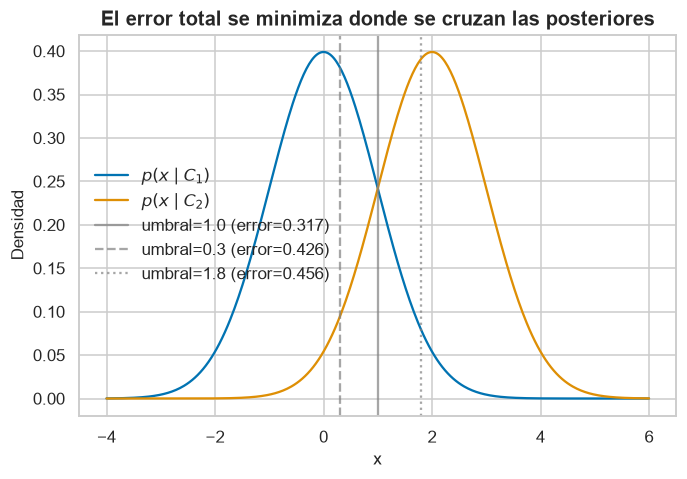

umbral=1.0: error total = 0.3167
umbral=0.3: error total = 0.4261
umbral=1.8: error total = 0.4561


In [10]:
def error_total(threshold, mu1=0.0, sigma1=1.0, mu2=2.0, sigma2=1.0):
    # Réplica de la celda 40 de la clase: área de las dos colas mal clasificadas.
    x = np.linspace(-4, 6, 4000)
    p1 = (1 / (np.sqrt(2 * np.pi) * sigma1)) * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
    p2 = (1 / (np.sqrt(2 * np.pi) * sigma2)) * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
    err1 = np.trapezoid(p1[x >= threshold], x[x >= threshold])   # C1 clasificado como C2
    err2 = np.trapezoid(p2[x < threshold], x[x < threshold])     # C2 clasificado como C1
    return err1 + err2, x, p1, p2

fig, ax = plt.subplots(figsize=(7, 4.5))
x_plot = np.linspace(-4, 6, 400)
mu1, mu2 = 0.0, 2.0
p1_plot = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x_plot - mu1) ** 2)
p2_plot = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x_plot - mu2) ** 2)
ax.plot(x_plot, p1_plot, label=r"$p(x \mid C_1)$")
ax.plot(x_plot, p2_plot, label=r"$p(x \mid C_2)$")

for umbral, estilo in [(1.0, "-"), (0.3, "--"), (1.8, ":")]:
    err, *_ = error_total(umbral)
    ax.axvline(umbral, linestyle=estilo, color="gray", alpha=0.7,
               label=f"umbral={umbral} (error={err:.3f})")

ax.set_xlabel("x")
ax.set_ylabel("Densidad")
ax.set_title("El error total se minimiza donde se cruzan las posteriores")
ax.legend()
plt.show()

for umbral in [1.0, 0.3, 1.8]:
    err, *_ = error_total(umbral)
    print(f"umbral={umbral}: error total = {err:.4f}")


La salida confirma la teoría: el umbral $1.0$ —el punto donde las dos curvas se
cruzan, porque las medias están a igual distancia y las varianzas son
iguales— da el error más chico de los tres. Cualquier otro umbral, para
cualquier lado, empeora.

### 🏭 Así se hace en la industria

La regla de Bayes de esta sección asume que conocés $\mu_1$, $\sigma_1$, $\mu_2$,
$\sigma_2$ y los priors. En la práctica no los conocés: tenés muestras, nada
más. Un clasificador generativo (§7) estima esos parámetros a partir de datos y
aplica la misma regla. Comprobemos que, con suficientes datos, `sklearn`
recupera el mismo umbral que calculamos a mano.


In [11]:
from sklearn.naive_bayes import GaussianNB

rng = np.random.default_rng(0)
x_c1 = rng.normal(0.0, 1.0, size=2000)
x_c2 = rng.normal(2.0, 1.0, size=2000)

X_entrenamiento = np.concatenate([x_c1, x_c2]).reshape(-1, 1)
y_entrenamiento = np.concatenate([np.zeros(2000), np.ones(2000)])

clasificador = GaussianNB().fit(X_entrenamiento, y_entrenamiento)

# Barremos el eje x y buscamos dónde el clasificador cambia de clase: ese es
# el umbral que "descubrió" a partir de los datos, sin que se lo diéramos.
x_barrido = np.linspace(-4, 6, 4000).reshape(-1, 1)
predicciones = clasificador.predict(x_barrido)
cambio = x_barrido[np.where(np.diff(predicciones) != 0)[0][0], 0]
print(f"Umbral aprendido por GaussianNB: {cambio:.3f}  (el óptimo teórico es 1.0)")


Umbral aprendido por GaussianNB: 0.984  (el óptimo teórico es 1.0)


Con 2000 observaciones por clase, `GaussianNB` recupera un umbral prácticamente
idéntico a 1.0: no le dimos $\mu_1$, $\mu_2$ ni $\sigma$, los estimó de los
datos y después aplicó exactamente la regla de Bayes de esta sección. Es lo que
hace por dentro cualquier clasificador generativo de la familia 1 de §7.

### ⚠️ Confusión típica

Decidir con la **verosimilitud** $p(x \mid C_k)$ en vez de con la **posterior**
$p(C_k \mid x)$. Es el error más común de todo el tema, y la figura lo esconde
porque ahí los priors son iguales y da igual.

Pensá una enfermedad que tiene 1 persona cada 10.000. Un test da positivo, y
resulta que el positivo es más "típico" de los enfermos que de los sanos: la
verosimilitud favorece "enfermo". Pero hay 9.999 sanos por cada enfermo, así que
la mayoría de los positivos vienen de sanos. La posterior —que multiplica la
verosimilitud por el prior— dice "sano", y es la que tiene razón. Por eso Bayes
lleva el $p(C_k)$ adentro: ignorarlo es ignorar cuánta gente hay de cada clase.

La segunda: creer que las regiones de decisión son intervalos o zonas conexas. La
celda 38 avisa explícitamente que no. Con dos gaussianas de distinta varianza, la
región de una clase puede ser "el centro" y la de la otra "las dos colas".


---

## 6. El mismo resultado, con la notación de Hastie: EPE y función de pérdida

📓 celdas 42–47 · 📕 ESL §2.4

### La idea en criollo

La clase vuelve a contar lo mismo que §5, ahora "con una notación más cargada
pero un poco más general" (celda 42). Y no es un capricho de notación: la
generalidad es real y es la que arregla el problema del detector de metales.

En §5 todos los errores valían igual: minimizábamos **cuántas** veces te
equivocás. Acá le vas a poder poner **precio** a cada tipo de error. Confundir un
gato con un perro y confundir un tumor benigno con uno maligno dejan de ser lo
mismo, que es como tiene que ser.

### Formalizándolo

Los objetos, con la notación de ESL:

- $G$ es la salida categórica, con valores en $\mathcal{G}$.
- $\hat{G}(X)$ es el estimador, que también toma valores en $\mathcal{G}$.
- $\textbf{L}$ es la **matriz de pérdida**, de $K \times K$: $L(k, \ell)$ es el
  costo de clasificar como $\mathcal{G}_\ell$ algo que en realidad era
  $\mathcal{G}_k$. Es **cero en la diagonal** (acertar no cuesta) y no negativa
  fuera de ella.
- La **zero-one loss** (o pérdida 0-1) es el caso particular en que $L = 0$ si
  $k = \ell$ y $L = 1$ si no. Todos los errores cuestan lo mismo.

Con eso se define el **error de predicción esperado**:

$$EPE = E\big[L(G, \hat{G}(X))\big]$$

La celda 43 hace la pregunta correcta: **¿sobre qué está tomada esa esperanza?**
Sobre la conjunta de $X$ y $G$. Escribámosla, entonces, abriendo la esperanza:
integramos sobre $X$ y sumamos sobre las $K$ clases posibles, cada término pesado
por su probabilidad.

$$EPE = \int_X \sum_{k=1}^{K} L(\mathcal{G}_k, \hat{G}(X))\, p(\mathcal{G}_k \mid X)\, p(X)\, dX$$

que se suele escribir de forma más compacta metiendo $p(X)\,dX$ dentro de un
operador esperanza:

$$EPE = E_X\left[\sum_{k=1}^{K} L(\mathcal{G}_k, \hat{G}(X))\, p(\mathcal{G}_k \mid X)\right]$$

Las dos expresiones dicen lo mismo. La segunda solo abrevia: como aclara la celda
44, $E_X[\cdot]$ es un **promedio ponderado por $p(X)$** sobre todos los valores
posibles de $X$.

**La minimización punto a punto.** La clase afirma que para minimizar el EPE
"basta con minimizarlo puntualmente", y —esto es lo bueno de esta clase— la celda
45 se detiene a justificarlo en vez de pasar de largo. Vale la pena seguir el
argumento con cuidado, porque es el mismo truco que va a reaparecer en §8.

Escribí el EPE separando lo de adentro:

$$EPE = \int_X \Bigg[\underbrace{\sum_{k=1}^{K} L(\mathcal{G}_k, \hat{G}(X))\, p(\mathcal{G}_k \mid X)}_{\text{error esperado local en }X}\Bigg] p(X)\, dX$$

El corchete es el error esperado **en ese punto $X$**, y depende de una sola
cosa que vos controlás: qué clase decidís predecir ahí. La decisión que tomás en
$x = 3$ no aparece en el corchete de $x = 7$.

Entonces el EPE es una suma (integral) de términos **independientes entre sí**,
uno por cada $X$, cada uno pesado por $p(X) \geq 0$. Y minimizar una suma de
términos independientes y no negativos es minimizar cada término por separado.
No hay ningún compromiso global que resolver: no existe un $x$ donde te convenga
decidir peor para ganar en otro lado.

De ahí sale la regla, ahora en su forma general:

$$\hat{G}(x) = \arg\min_{g \in \mathcal{G}} \sum_{k=1}^{K} L(\mathcal{G}_k, g)\, p(\mathcal{G}_k \mid X = x)$$

En castellano: para cada $x$, probá todas las clases que podrías predecir; para
cada una, calculá cuánto te costaría en promedio; quedate con la más barata.

**El caso 0-1.** Metamos la pérdida 0-1 en esa fórmula. Si predecís $g$, el
término $L(\mathcal{G}_k, g)$ vale 0 cuando $\mathcal{G}_k = g$ y 1 en los otros
$K-1$ casos. Así que la suma es la probabilidad de todas las clases **menos** la
que elegiste:

$$\sum_{k=1}^{K} L(\mathcal{G}_k, g)\, p(\mathcal{G}_k \mid x) = \sum_{k:\, \mathcal{G}_k \neq g} p(\mathcal{G}_k \mid x) = 1 - p(g \mid x)$$

(La última igualdad es porque las posteriores suman 1.) Entonces:

$$\hat{G}(x) = \arg\min_{g \in \mathcal{G}} \big[1 - p(g \mid X = x)\big]$$

y minimizar $1 - p(g \mid x)$ es maximizar $p(g \mid x)$:

$$\hat{G}(x) = \mathcal{G}_k \quad \text{si} \quad p(\mathcal{G}_k \mid X = x) = \max_{g \in \mathcal{G}} p(g \mid X = x)$$

### ❓ La pregunta que quedó abierta

La celda 43 pregunta, después de escribir el EPE: *"¿Se parece a lo que vimos
antes (Bishop)?"* — y no contesta.

**Es exactamente lo mismo.** La última fórmula de arriba y la
$\hat{G} = \arg\max_{C_k} p(C_k \mid x)$ de §5 son la misma regla escrita en dos
dialectos. Acá va la traducción, símbolo por símbolo:

| Concepto | §5, notación de Bishop | §6, notación de Hastie / ESL |
|---|---|---|
| Las clases | $C_1, C_2, \ldots$ | $\mathcal{G}_1, \mathcal{G}_2, \ldots$, con $G \in \mathcal{G}$ |
| Posterior | $p(C_k \mid x)$ | $p(\mathcal{G}_k \mid X = x)$ |
| Qué se minimiza | $p(\text{error})$ | $EPE = E[L(G, \hat{G}(X))]$ |
| Cómo se pesa el error | implícito: todos valen 1 | explícito: la matriz $\textbf{L}$ |
| La decisión | regiones $\mathcal{R}_k$ | la función $\hat{G}(x)$ |
| El resultado | $\arg\max_k p(C_k \mid x)$ | $\arg\min_g \sum_k L(\mathcal{G}_k, g)\, p(\mathcal{G}_k \mid x)$ |

La única diferencia real está en la penúltima fila: Bishop **fija** la pérdida
0-1 desde el arranque, Hastie la deja como parámetro. Poné $L$ = 0-1 en la
fórmula de Hastie y te cae la de Bishop, que es la cuenta que acabamos de hacer.
Son un caso general y un caso particular, no dos teorías.

Si te quedó la sensación de haber visto dos temas distintos en §5 y §6, era eso:
uno solo, contado dos veces.

### ¿Por qué nos importa?

Porque las pérdidas asimétricas son la norma, no la excepción, y con 0-1 no las
podés expresar.

Volvamos al Ejemplo 1 y supongamos que el costo de decir "aprueba" cuando en
realidad no aprueba es **5 veces** el costo del error opuesto (pensá que en base
a eso se decide si mandarle apoyo extra a alguien: no mandárselo a quien lo
necesita es caro). Con $L(0,1) = 5$ y $L(1,0) = 1$, el costo de cada decisión en
un punto $x$ es:

- predecir $Y = 1$: $\;5 \cdot p(Y{=}0 \mid x)$
- predecir $Y = 0$: $\;1 \cdot p(Y{=}1 \mid x)$

Predecís 1 solo cuando $5\,p(Y{=}0 \mid x) < p(Y{=}1 \mid x)$. Llamando
$p_1 = p(Y{=}1 \mid x)$, eso es $5(1 - p_1) < p_1$, o sea
$p_1 > 5/6 \approx 0{,}833$.

El umbral se corrió de $0{,}5$ a $0{,}833$. Verifiquemos con código cuántas
celdas de la tabla del Ejemplo 1 cambian de decisión.

### En código


In [12]:
p1 = np.array([[0.1, 0.2], [0.3, 0.6], [0.4, 0.7], [0.5, 0.8], [0.9, 0.95]])
p0 = 1 - p1

def decidir(p0, p1, L):
    # L[k, l] = costo de predecir l cuando la verdad era k.
    costo_pred0 = L[0, 0] * p0 + L[1, 0] * p1   # riesgo esperado de predecir 0
    costo_pred1 = L[0, 1] * p0 + L[1, 1] * p1   # riesgo esperado de predecir 1
    return (costo_pred1 < costo_pred0).astype(int)

L_01 = np.array([[0, 1], [1, 0]])        # zero-one loss
L_asim = np.array([[0, 5], [1, 0]])      # el falso "aprueba" cuesta 5 veces más

decision_01 = decidir(p0, p1, L_01)
decision_asim = decidir(p0, p1, L_asim)

print("Con pérdida 0-1:\n", decision_01, "  -> predice 1 en", decision_01.sum(), "celdas")
print("Con pérdida asimétrica:\n", decision_asim, "  -> predice 1 en", decision_asim.sum(), "celdas")


Con pérdida 0-1:
 [[0 0]
 [0 1]
 [0 1]
 [0 1]
 [1 1]]   -> predice 1 en 5 celdas
Con pérdida asimétrica:
 [[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]]   -> predice 1 en 2 celdas


La salida confirma la cuenta: con pérdida 0-1 predecís "aprueba" en 5 celdas;
con la pérdida asimétrica, solo en 2 (las de $X_1 = 4$, donde $p_1$ ya supera
$0{,}833$). Fijate que `decidir` no sabe nada de "aprobar" ni de umbrales:
implementa literalmente el $\arg\min_g \sum_k L(\mathcal{G}_k, g)\, p(\mathcal{G}_k \mid x)$
de la teoría, comparando dos riesgos esperados. El umbral $5/6$ es una
*consecuencia* de la matriz de pérdida, no algo que se programe.

### ⚠️ Confusión típica

Leer $L(k, \ell)$ al revés. El **primer** índice es la clase verdadera y el
segundo es la predicha. $L(0, 1) = 5$ significa "era 0 y predije 1". Si los
intercambiás, la matriz asimétrica te empuja las decisiones para el lado
contrario y el resultado va a parecer razonable igual, que es lo peligroso.

La segunda, más de fondo: creer que la minimización punto a punto es una
aproximación o una simplificación. No lo es, es exacta — pero **solo** porque no
hay ninguna restricción que ate las decisiones de distintos $x$ entre sí. Si
alguien te pusiera un límite del tipo "no podés predecir la clase 1 en más del
10% de los casos", el argumento de la celda 45 se cae y ya no podés optimizar
cada punto por separado.


---

## 7. Por qué hay que modelar: las tres familias

📓 celdas 48–52 · 📘 Bishop §1.5.4

### La idea en criollo

Las celdas 48 a 50 arman el argumento en tres golpes cortos:

> Ya sabemos cómo usar $p(X, G)$ para decidir. **Pero determinar $p(X, G)$ suele
> ser muy difícil.**
>
> ¿Por qué? Porque $X$ suele ser un vector de **alta dimensión**, y estimar
> distribuciones en alta dimensión es muy difícil.
>
> ¿La solución? **Modelar.**

Es la caída de la fantasía de §3. La tabla completa era una maravilla mientras
tenía 20 números. La cuenta que hace explotar todo es simple: si $X$ tiene $p$
componentes binarias, la tabla tiene $2^p$ filas. Con $p = 10$ son 1024, todavía
manejable. Con $p = 50$ son $10^{15}$ filas — más celdas que observaciones vas a
tener nunca, así que la enorme mayoría quedan vacías. Y si $X$ es continua, ni
siquiera hay filas que contar.

Modelar es aceptar eso y cambiar de estrategia: en vez de estimar cada celda por
separado, **suponer una forma** para la distribución y estimar los pocos
parámetros que esa forma tiene. Una normal multivariada en $p = 50$ dimensiones
se describe con un vector de medias y una matriz de covarianza: unos pocos miles
de números en lugar de $10^{15}$.

> **Dónde se rompe la analogía** de "suponer una forma": estás cambiando datos
> por supuestos. Si la forma que elegiste está cerca de la verdad, ganaste mucho;
> si está lejos, tu modelo va a estar seguro de cosas falsas. Ese canje tiene
> nombre y apellido —sesgo contra varianza— y es el tema de 📕 ESL §2.9.

### Formalizándolo

La celda 51 separa el problema de clasificación en **dos instancias**, y la
distinción vale para toda la materia:

- **Inferencia**: usar los datos de entrenamiento para estimar $p(X, G)$ o
  $p(G \mid X)$.
- **Decisión**: usar esa distribución estimada para predecir la clase ante un $X$
  nuevo — lo de §5 y §6.

Y la celda 52 lista **tres aproximaciones**, ordenadas de más a menos ambiciosa:

**1. Modelos generativos.** Modelan la conjunta $p(X, G)$; de ahí obtienen
$p(G \mid X)$ normalizando; y después aplican teoría de la decisión. Se llaman
generativos porque, al tener la conjunta, podés **generar datos sintéticos** en
el espacio de entrada: sabés cómo se distribuyen las $X$, no solo cómo se
relacionan con $G$. Ejemplo típico de la materia: análisis discriminante
(📕 ESL §4.3) — el "Ejemplo 3" que la clase dejó pendiente en la celda 34. El
`GaussianNB` de §5 es exactamente esto: estima $p(x \mid C_k)$ y el prior, y de
ahí saca la posterior.

**2. Modelos discriminativos.** Modelan directamente $p(G \mid X)$ y aplican
teoría de la decisión. No se ocupan de cómo se distribuye $X$, porque para
decidir no hace falta — es justo lo que quedó demostrado en §5, donde $p(x)$ se
cancelaba. Ejemplo típico: regresión logística (📕 ESL §4.4).

**3. Funciones discriminantes.** Aprenden directamente una función que mapea $X$
a una clase. **No modelan ninguna distribución de probabilidad**: fusionan
inferencia y decisión en un solo paso. Ejemplos: SVM, $k$-vecinos.

Lo que se gana bajando en la lista es que cada vez tenés que estimar menos cosas,
y estimar menos cosas es más fácil. Lo que se pierde son las probabilidades: una
función discriminante te dice "clase 1" y nada más. No te puede decir qué tan
segura está, no te deja cambiar la matriz de pérdida sin reentrenar, y no te
avisa cuando el punto que le diste no se parece a nada que haya visto.

### ¿Por qué nos importa?

Porque es el índice del resto de la materia. Cada modelo que veas de acá en
adelante cae en una de estas tres cajas, y saber en cuál está te dice de entrada
qué podés esperar de él y qué no.

También explica por qué la conversación sobre teoría de la decisión venía
**antes** que cualquier modelo. Las familias 1 y 2 terminan las dos en el mismo
lugar: con una posterior en la mano y la necesidad de decidir. La maquinaria de
§6 es la que usan las dos.

### ⚠️ Confusión típica

"Discriminativo" y "función discriminante" suenan igual y son cosas distintas.
Un modelo **discriminativo** sí estima probabilidades (las posteriores); lo que
no estima es $p(X)$. Una **función discriminante** no estima ninguna
probabilidad. Los nombres son desafortunados, pero son los que se usan.

La segunda: creer que "generativo" quiere decir "genera texto o imágenes". El
término es muy anterior a los modelos generativos de moda, y significa
exactamente lo que dice la celda 52: modela la conjunta, y por lo tanto **podría**
generar muestras de $X$. Un análisis discriminante lineal es un modelo generativo
en este sentido — igual que el `GaussianNB` de §5.


---

## 8. Decisión en regresión: la media condicional

📓 celdas 53–55 · 📕 ESL §2.4 · 📘 Bishop §1.5.5

### La idea en criollo

Todo §5, §6 y §7 fue con $G$ categórica. Ahora la salida es un número real, y hay
que rehacer la pregunta: dado $x$, ¿qué **valor** predecir?

La respuesta va a resultar tan familiar que da un poco de bronca: el promedio.
Pero es un promedio muy específico: el promedio de los $Y$ **entre las
observaciones que comparten ese $x$**. No el promedio general.

### Formalizándolo

El planteo de la celda 53:

- $X \in \mathbb{R}^p$ son los atributos, $Y \in \mathbb{R}$ el valor a predecir,
  $p(X, Y)$ su conjunta.
- Buscamos una función $f(X)$ que prediga $Y$.
- La pérdida típica es la **cuadrática**: $L(Y, f(X)) = (Y - f(X))^2$.

Con eso el error de predicción esperado es

$$EPE(f) = E\big[(Y - f(X))^2\big] = \iint (y - f(x))^2\, p(x, y)\, dy\, dx$$

Condicionamos con la regla del producto, $p(x, y) = p(y \mid x)\, p(x)$:

$$EPE(f) = \iint (y - f(x))^2\, p(y \mid x)\, p(x)\, dy\, dx = E_X\,E_{Y \mid X}\big[(Y - f(X))^2 \mid X\big]$$

Y estamos de nuevo en la situación de la celda 45: una integral sobre $X$, con
peso $p(x) \geq 0$, de un término que depende **solo** de la decisión que tomás
en ese $x$. Mismo argumento, misma conclusión: alcanza con minimizar punto a
punto. Para cada $x$ fijo buscamos el número $c$ que minimiza

$$f(x) = \arg\min_{c \in \mathbb{R}} E_{Y \mid X}\big[(Y - c)^2 \mid X = x\big]$$

La clase escribe directamente "cuya solución es $f(x) = E(Y \mid X = x)$".
Hagamos ese paso, que son dos líneas. Derivamos respecto de $c$ y metemos la
derivada adentro de la esperanza (podemos: la esperanza es una integral en $y$, y
$c$ no depende de $y$):

$$\frac{d}{dc}\, E\big[(Y - c)^2 \mid x\big] = E\big[-2(Y - c) \mid x\big] = -2\big(E[Y \mid x] - c\big)$$

Igualando a cero: $c = E[Y \mid x]$. Y es un mínimo, no un máximo, porque la
derivada segunda es $2 > 0$. Entonces

$$\boxed{\;f(x) = E(Y \mid X = x)\;}$$

que es la llamada **función de regresión**. En palabras, tal como lo dice la
celda 54: *la mejor predicción de $Y$ en un punto $x$ es la media condicional,
cuando el error se mide con la pérdida cuadrática.*

**Cuánto error queda.** Hay un bonus que sale de la misma cuenta y que la clase no
menciona. Sumando y restando $E[Y \mid x]$ dentro del cuadrado se llega a

$$E\big[(Y - c)^2 \mid x\big] = \underbrace{\operatorname{Var}(Y \mid x)}_{\text{no depende de } c} + \big(E[Y \mid x] - c\big)^2$$

El segundo término es lo único que controlás, y elegir $c = E[Y \mid x]$ lo hace
cero. Lo que queda es $\operatorname{Var}(Y \mid x)$: **el error irreducible**.
Es el análogo exacto del error de Bayes de §5, y es el $\epsilon$ de §1
apareciendo por tercera vez. Aunque conocieras $p(X, Y)$ perfecta, ese error
sigue ahí.

**Las tres aproximaciones, en versión regresión.** La celda 55 replica para
regresión la lista de §7:

1. Modelar la conjunta $p(X, Y)$, condicionar y sacar el promedio condicional.
2. Modelar directamente la condicional $p(Y \mid X)$ y sacar su promedio.
3. Modelar directamente $E[Y \mid X]$, sin pasar por ninguna distribución.

La opción 3 es la que va a usar la próxima clase: la regresión lineal supone que
$E(Y \mid X)$ es (aproximadamente) una función lineal de $X$ y estima sus
coeficientes. Nunca escribe una distribución. Ahora ya sabés por qué eso es
legítimo: porque la media condicional era, desde el principio, lo único que hacía
falta.

### ¿Por qué nos importa?

Porque le da sentido a algo que si no parece arbitrario. Cuando en la próxima
clase la primera línea diga "asumimos que $E(Y \mid X)$ es lineal", eso no sale de
la nada: **la esperanza condicional es la respuesta óptima** bajo error
cuadrático, y el modelo lineal es una manera barata de aproximarla.

También cierra el paralelo entre las dos ramas de la materia, que es el resumen
de la clase entera:

| | Clasificación | Regresión |
|---|---|---|
| Salida | $G$, categórica | $Y$, continua |
| Pérdida típica | 0-1 | cuadrática |
| Decisión óptima | $\arg\max_g p(g \mid x)$ | $E(Y \mid X = x)$ |
| Error irreducible | error de Bayes | $\operatorname{Var}(Y \mid x)$ |

Es **una sola** teoría con dos instancias: elegí una pérdida, minimizá el riesgo
esperado punto a punto, y quedate con lo que salga.

### En código

Con datos sintéticos se ve que la media condicional le gana a cualquier otra
constante en cada $x$.


Error máx. vs sin(x) verdadero: 0.0361545031101074
Varianza residual (piso irreducible): 0.254104270634563


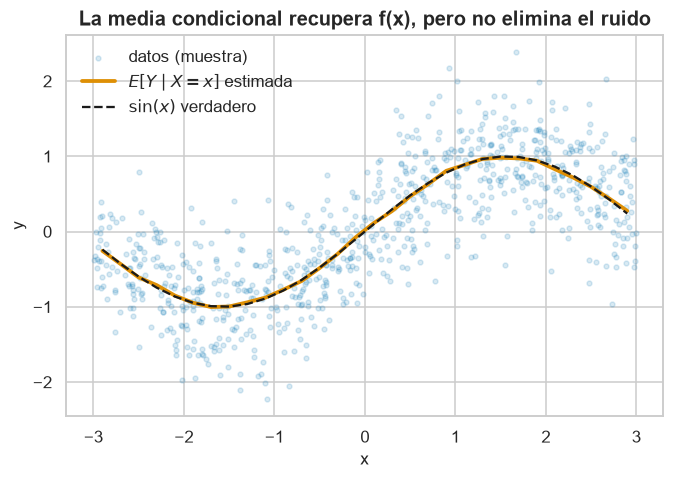

In [13]:
rng = np.random.default_rng(0)
x = rng.uniform(-3, 3, 20_000)
y = np.sin(x) + rng.normal(0, 0.5, 20_000)   # f(x) = sin(x), ruido sigma = 0.5

# Estimamos E[Y|X=x] "a lo bruto": promediamos y dentro de cada bin de x.
bins = np.linspace(-3, 3, 31)
idx = np.digitize(x, bins)
media_cond = np.array([y[idx == b].mean() for b in range(1, len(bins))])
centros = (bins[:-1] + bins[1:]) / 2

print("Error máx. vs sin(x) verdadero:", np.abs(media_cond - np.sin(centros)).max())

# El error que queda es la varianza condicional: sigma^2 = 0.25, no cero.
resid = y - np.sin(x)
print("Varianza residual (piso irreducible):", resid.var())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x[:800], y[:800], alpha=0.15, s=10, label="datos (muestra)")
ax.plot(centros, media_cond, color="C1", linewidth=2.5, label=r"$E[Y\mid X=x]$ estimada")
ax.plot(centros, np.sin(centros), color="k", linestyle="--", label=r"$\sin(x)$ verdadero")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("La media condicional recupera f(x), pero no elimina el ruido")
ax.legend()
plt.show()


La segunda cuenta es la importante: aun usando la $f$ **verdadera** ($\sin x$),
el error cuadrático medio no baja de $0{,}25 = \sigma^2$ (la salida lo confirma).
Ese es el piso del que venimos hablando desde §1. El gráfico muestra las dos
cosas a la vez: la curva naranja (la media condicional estimada) prácticamente
se superpone a la negra (la $f$ verdadera), pero los puntos siguen dispersos
alrededor — esa dispersión **es** $\operatorname{Var}(Y\mid x)$, y ninguna $f$
la elimina.

### 🏭 Así se hace en la industria

Toda esta sección asumió pérdida **cuadrática**, que es la que hace óptima a la
media. Si la pérdida fuera **absoluta** ($|Y - f(X)|$), el óptimo pasa a ser la
**mediana** condicional — el mismo argumento de minimización punto a punto,
distinta cuenta puntual. En la práctica no hace falta rederivarlo: se usa
directamente un regresor de cuantiles.


In [14]:
from sklearn.linear_model import QuantileRegressor

# Metemos un outlier grosero para ver cómo reacciona cada estimador.
x_train = rng.uniform(-3, 3, 500).reshape(-1, 1)
y_train = np.sin(x_train).ravel() + rng.normal(0, 0.3, 500)
y_train[0] = 50.0   # outlier

media_con_outlier = y_train.mean()
mediana_con_outlier = np.median(y_train)

q50 = QuantileRegressor(quantile=0.5, alpha=0.0, solver="highs").fit(np.zeros_like(x_train), y_train)

print(f"Media (sensible al outlier):    {media_con_outlier:.3f}")
print(f"Mediana (robusta):              {mediana_con_outlier:.3f}")
print(f"QuantileRegressor q=0.5 (Intercepto): {q50.intercept_:.3f}")


Media (sensible al outlier):    0.133
Mediana (robusta):              0.023
QuantileRegressor q=0.5 (Intercepto): 0.026


El outlier de $50$ arrastra la media muy por encima de dónde realmente están
los datos (que oscilan entre $-1$ y $1$), mientras que la mediana —y el
`QuantileRegressor` con `quantile=0.5`, que converge al mismo número—
prácticamente ni se entera. Es la consecuencia práctica de cambiar la pérdida
cuadrática por la absoluta: **guardate esto**, porque es literalmente el
Ejercicio 1 de la próxima clase.

### ⚠️ Confusión típica

Creer que "la mejor predicción es el promedio" es una verdad universal. Es
verdad **para la pérdida cuadrática**. Cambiá la pérdida y cambia la respuesta:
con pérdida absoluta $|Y - f(X)|$ el óptimo es la **mediana** condicional, no la
media. Por eso la mediana es más robusta a valores extremos — un dato disparatado
mueve mucho un promedio y casi nada una mediana, tal como acabamos de ver.


---

## 🧵 El hilo conductor

La clase avisa en la celda 0 que va a "volcar un montón de ingredientes" antes de
cocinar nada, y es literal. Pero los ingredientes están en un orden que no es
casual, y visto desde el final se lee como un solo argumento encadenado.

Arranca fijando cómo se escribe todo (§0), porque sin eso las fórmulas que
siguen no se pueden ni leer. Después define de qué estamos hablando: hay
problemas con etiqueta y sin etiqueta, y aun teniendo etiqueta podés querer dos
cosas distintas, predecir o entender (§1). Con eso se planta la ecuación que
gobierna la materia, $Y = f(X) + \epsilon$, y con ella la primera aparición de
algo que va a volver tres veces: hay una parte del problema que **no se puede
arreglar**.

Después viene la formalización, que resulta ser sorprendentemente chica: dos
reglas de probabilidad, de las que sale Bayes y todo lo demás (§2). Con ese
lenguaje se puede enunciar la ambición máxima: conocer $p(X, Y)$ sería tener el
problema resuelto, y los ejemplos muestran qué se puede hacer con ella cuando la
tenés (§3, §4).

Y entonces la clase se pega el volantazo que la define, en la celda 36: tener la
distribución **no es** tener la predicción. Ahí nace la teoría de la decisión,
contada dos veces —minimizando la probabilidad de error a la Bishop (§5) y
minimizando un riesgo esperado con matriz de pérdida a la Hastie (§6)— que
terminan siendo la misma cosa, con la segunda un poco más general. La respuesta
en clasificación es quedarse con la clase más probable.

Recién ahí llega la mala noticia, y llega bien puesta: la conjunta que
necesitábamos es imposible de estimar en dimensión alta, así que no queda otra
que modelar, y según cuánto modeles nacen las tres familias de métodos (§7). Ese
párrafo es, en los hechos, el índice de lo que queda de la materia.

El cierre repite el argumento entero para regresión y llega a la media
condicional (§8), que es la puerta de entrada a la próxima clase: **regresión
lineal** es suponer que esa media condicional es lineal en $X$ y estimarla por
cuadrados mínimos. Cuando la veas empezar con "asumimos que $E(Y \mid X)$ es
lineal", vas a saber de dónde salió ese objeto y por qué es el que hay que
aproximar.

## ✅ Autoevaluación

**1.** ¿Cuál es la diferencia entre $x_i$ y $\textbf{x}_j$? ¿Cuántas componentes
tiene cada uno?

<details><summary>Respuesta</summary>

$x_i$ (sin negrita) es la observación $i$-ésima: tiene $p$ componentes, una por
variable, y es una **fila** de $\textbf{X}$. $\textbf{x}_j$ (con negrita) son
todas las observaciones de la variable $j$-ésima: tiene $N$ componentes y es una
**columna**. La negrita es justamente la marca de "esto tiene $N$ componentes".
Y como todos los vectores se asumen columna, la fila $i$ de $\textbf{X}$ se
escribe $x_i^T$.

</details>

**2.** En $Y = f(X) + \epsilon$, ¿por qué no se puede eliminar $\epsilon$
consiguiendo más datos?

<details><summary>Respuesta</summary>

Porque $\epsilon$ no es un defecto de tu estimación: es parte del fenómeno. Junta
todo lo que hace variar a $Y$ y que $X$ **no contiene** — variables que no
mediste, ruido del instrumento, azar. Más datos mejoran tu $\hat{f}$ y la acercan
a $f$, pero aunque llegaras a $\hat f = f$ exactamente, seguirías sin poder
predecir $\epsilon$. Lo único que puede reducirlo es cambiar $X$: **medir mejores
atributos**, no juntar más filas.

</details>

**3.** Tenés $p(X, Y)$ y tenés $p(Y \mid X)$. ¿Contienen la misma información?

<details><summary>Respuesta</summary>

No: la conjunta contiene estrictamente más. De $p(X,Y)$ sacás $p(Y \mid X)$ **y**
la marginal $p(X)$, usando las dos reglas de §2. Al revés no: de la condicional
sola no podés recuperar $p(X)$, perdiste el dato de qué tan frecuente es cada
$x$.

Para *decidir* eso no importa —en §5 vimos que $p(x)$ se cancela de la regla—,
pero sí importa para saber cuánto pesa cada error en el error total, y es
exactamente la diferencia entre un modelo generativo y uno discriminativo (§7).

</details>

**4.** Con la tabla condicional del Ejemplo 1 y pérdida 0-1, ¿qué predecís para
un alumno con $X_1 = 3$ (tres horas de estudio) y $X_2 = 0$ (no fue a clase)?

<details><summary>Respuesta</summary>

Es un empate: $P(Y{=}0 \mid x) = P(Y{=}1 \mid x) = 0{,}5$. La regla de Bayes es
indiferente, y cualquiera de las dos decisiones da el mismo riesgo esperado
($0{,}5$). Lo importante es lo que significa: en ese punto te vas a equivocar la
mitad de las veces **hagas lo que hagas**, porque el problema es genuinamente
ambiguo ahí. No es un defecto del modelo.

Con una pérdida asimétrica el empate se rompe: si el falso "aprueba" cuesta 5
veces más, el umbral se corre a $5/6$ y en esta celda predecís $Y = 0$ — la
celda de código de §6 lo confirma.

</details>

**5.** ¿Por qué se puede minimizar el EPE punto a punto, en lugar de tener que
optimizar globalmente?

<details><summary>Respuesta</summary>

Porque el EPE se escribe como
$\int_X [\,\text{error local en } X\,]\, p(X)\, dX$, y ese corchete depende
**solo** de la decisión que tomás en ese $X$: la decisión en un punto no aparece
en el corchete de ningún otro. Es una suma de términos independientes, cada uno
pesado por $p(X) \geq 0$, así que minimizar la suma es minimizar cada término.

El supuesto oculto es que no hay ninguna restricción que ate las decisiones entre
sí. Si te impusieran algo como "no podés predecir la clase 1 en más del 10% de
los casos", el argumento se cae y volvés a tener un problema global.

</details>

**6.** Calculá el error de Bayes del Ejemplo 1 y explicá qué significa el número.

<details><summary>Respuesta</summary>

En cada celda te equivocás con probabilidad $\min(P(Y{=}0 \mid x), P(Y{=}1 \mid x))$,
y todas las celdas tienen $P(x) = 0{,}1$ — el cálculo de §5 lo confirma
numéricamente:

$$0{,}1 \times \big[(0{,}1{+}0{,}3{+}0{,}4{+}0{,}5{+}0{,}1) + (0{,}2{+}0{,}4{+}0{,}3{+}0{,}2{+}0{,}05)\big] = 0{,}1 \times 2{,}55 = 0{,}255$$

**25,5%.** Es el error mínimo alcanzable por *cualquiera* que conozca la
distribución verdadera. Si construís un clasificador y te da 27% de error, estás
a 1,5 puntos del óptimo teórico: tu modelo está bien y el problema es difícil.
Bajar del 25,5% con estos dos atributos es imposible; para lograrlo habría que
**agregar atributos**.

</details>

**7.** ¿Qué pasa con la decisión óptima si cambiás la pérdida cuadrática por la
pérdida absoluta en un problema de regresión?

<details><summary>Respuesta</summary>

Deja de ser la media condicional y pasa a ser la **mediana** condicional. La
maquinaria es idéntica —minimizás el riesgo esperado punto a punto—, lo que
cambia es qué constante minimiza ese riesgo local: para $(Y-c)^2$ es
$E[Y \mid x]$, para $|Y - c|$ es la mediana de $Y \mid x$.

Consecuencia práctica, la que viste en la celda de "así se hace en la
industria" de §8: la pérdida absoluta es mucho más robusta a valores extremos,
porque un dato disparatado corre bastante un promedio y casi nada una mediana.
Es literalmente el Ejercicio 1 de la clase de regresión lineal.

</details>

**8.** Un modelo te devuelve solo una etiqueta de clase, sin ninguna
probabilidad. ¿A qué familia pertenece, y qué perdiste?

<details><summary>Respuesta</summary>

Es una **función discriminante**: fusiona inferencia y decisión en un paso y no
modela ninguna distribución.

Perdiste tres cosas concretas. No podés saber qué tan segura está la predicción
(todas las etiquetas te llegan con la misma autoridad). No podés cambiar la
matriz de pérdida sin reentrenar, porque la decisión ya viene tomada adentro del
modelo — todo §6 te queda inaccesible. Y no tenés cómo detectar que el punto que
le pasaste no se parece a nada de lo que vio en entrenamiento, algo que un modelo
generativo sí te puede señalar vía $p(x)$ — como el `GaussianNB` de §5, que
además de clasificar te da `predict_proba`.

</details>

## 🎯 Centros para los ejercicios

### Ejercicio 1 — Elegir atributos con poder predictivo

- **De qué va realmente:** es el ejercicio que le da sentido a $Y = f(X) + \epsilon$.
  Elegir atributos es elegir **cuánto de la variabilidad de $Y$ va a caer del lado
  de $f$ y cuánto va a quedar en $\epsilon$**. No hay una respuesta correcta, pero
  sí hay respuestas mejores y peores, y el criterio para distinguirlas es lo que
  se está evaluando.
- **Por dónde arrancar:** para cada problema, escribí primero **qué es una
  observación** (¿un viaje? ¿un colectivo? ¿un día?). Definir la unidad antes que
  los atributos te ordena todo lo demás y evita mezclar niveles. Recién después
  listá atributos, y pasá cada uno por tres filtros: ¿está disponible **en el
  momento de predecir**? ¿es medible sin un esfuerzo desproporcionado? ¿tenés una
  razón para creer que se relaciona con $y$?
- **Con qué chequear:** el filtro que más ejercicios arruina es el primero. En el
  de fraude con tarjeta, "el cliente después reclamó la operación" es un atributo
  buenísimo y completamente inútil, porque no existe cuando tenés que decidir.
  Repasá tu lista buscando ese tipo de trampa — se llama *fuga de información* y
  vas a chocar con ella toda la carrera. Segundo chequeo: para cada atributo,
  ¿podés contar en una oración por qué debería importar? Si no podés, no lo pongas.
- **⚠️ Dónde te vas a trabar:** en el último (texto de LLM vs. humano), porque los
  atributos obvios son textuales y no numéricos. No te frenes ahí: pensá en
  cantidades que se puedan **medir** sobre un texto (longitud de oraciones,
  variedad de vocabulario, frecuencia de ciertas construcciones, regularidad del
  ritmo) y no en el texto crudo. Convertir algo no numérico en atributos medibles
  es exactamente el trabajo.

### Ejercicio 2 — ¿Aprendizaje automático o no?

- **De qué va realmente:** el aprendizaje automático sirve cuando hay una relación
  que **existe pero no sabés escribir**, y tenés ejemplos de ella. Si la regla ya
  se conoce y se puede programar, o si directamente no hay ejemplos, es la
  herramienta equivocada. Este ejercicio es el filtro previo a todo lo demás de la
  materia.
- **Por dónde arrancar:** hacele a cada problema dos preguntas, en este orden.
  Primera: ¿existe un algoritmo exacto y conocido que lo resuelva? Segunda:
  ¿tengo (o puedo conseguir) pares $(x_i, y_i)$ con la respuesta correcta? Si la
  primera es "sí", no necesitás aprender nada. Si la segunda es "no", no podés
  aprender nada.
- **Con qué chequear:** dos de los cinco son casos donde la respuesta exacta ya
  existe y usar aprendizaje automático sería reemplazar una certeza por una
  aproximación peor. Si te dieron los cinco como problemas de ML, revisalos de
  nuevo. Y fijate en el enunciado que el de los caños dice **"calcular la
  probabilidad"**: ese detalle no es casual, cambia qué tipo de problema es.
- **⚠️ Dónde te vas a trabar:** en distinguir "no conviene" de "no se puede". Con
  suficientes ejemplos, un modelo puede aprender a reconocer números primos chicos
  con bastante acierto — no es que *no se pueda*. Es que hay un algoritmo exacto,
  rápido y siempre correcto, y cambiarlo por un modelo que a veces se equivoca es
  una mala decisión de ingeniería, no una imposibilidad. Redactá tus respuestas
  distinguiendo esos dos casos: la pregunta final del enunciado ("¿qué otros
  enfoques se te ocurren?") apunta justo a eso.
